## PROBLEM STATEMENT-1 - GROUP_17

**2024AA05952** -- PATIL NILESH NAVAL

**2024AA05118** -- MANISH GARG

**2024AA05007** -- KAVURI VENKATA DURGA BHARADWAJ

**2024AA05078** -- SUKAMATI NAVEEN KUMAR

**2024AB05269** -- LIKHITH S GOWDA



## 1. Data Loading & Preprocessing

* Loaded Boston Housing dataset using fetch_openml (as load_boston is deprecated).

* Split data into training and test sets to enable model evaluation.

* Applied standard scaling to features for improved optimizer convergence.

In [ ]:
# We used common packages for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# We used fetch_openml to load the Boston Housing dataset since load_boston is deprecated
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

# We added memory profiling capability to analyze resource efficiency
!pip install memory_profiler
from memory_profiler import memory_usage
import time  # For timing CPU execution

# ---- Data Loading and Preprocessing ----
# We loaded the Boston Housing dataset from OpenML and split it for training/testing
boston = fetch_openml(data_id=531, as_frame=True)  # Boston Housing: data_id=531
X = boston.data
y = boston.target.astype(np.float64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 2. Optimizer Implementations

## Defined three custom optimizers:

* Batch Gradient Descent (BGD): Uses the entire dataset for parameter update in every epoch.

* Stochastic Gradient Descent (SGD): Updates parameters using mini-batches for faster convergence and increased stochasticity.

* Momentum Gradient Descent: Incorporates momentum to accelerate training and smooth loss landscape traversal.

**Parameters (learning rate, batch size, epochs, momentum) are configurable for experimentation.**

In [ ]:
# ---- Optimizer Implementations ----
# We defined three manual optimizers to compare their convergence and efficiency
def batch_gradient_descent(X, y, lr=0.01, epochs=100):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    losses = []
    # Epoch loop for BGD
    for epoch in range(epochs):
        y_pred = np.dot(X, weights) + bias
        error = y_pred - y
        dw = np.dot(X.T, error) / n_samples
        db = np.sum(error) / n_samples
        weights -= lr * dw
        bias -= lr * db
        loss = np.mean(error ** 2)
        losses.append(loss)
    return weights, bias, losses

def stochastic_gradient_descent(X, y, lr=0.01, epochs=100, batch_size=16):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    losses = []
    for epoch in range(epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_shuffled, y_shuffled = X[indices], y[indices]
        epoch_loss = 0
        # We processed mini-batches for SGD
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            y_pred = np.dot(X_batch, weights) + bias
            error = y_pred - y_batch
            dw = np.dot(X_batch.T, error) / batch_size
            db = np.sum(error) / batch_size
            weights -= lr * dw
            bias -= lr * db
            batch_loss = np.mean(error ** 2)
            epoch_loss += batch_loss
        losses.append(epoch_loss / (n_samples // batch_size))
    return weights, bias, losses

def momentum_gradient_descent(X, y, lr=0.01, momentum=0.9, epochs=100):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    v_w = np.zeros(n_features)
    v_b = 0
    losses = []
    # We added velocity terms for momentum-based updates
    for epoch in range(epochs):
        y_pred = np.dot(X, weights) + bias
        error = y_pred - y
        dw = np.dot(X.T, error) / n_samples
        db = np.sum(error) / n_samples
        v_w = momentum * v_w + lr * dw
        v_b = momentum * v_b + lr * db
        weights -= v_w
        bias -= v_b
        loss = np.mean(error ** 2)
        losses.append(loss)
    return weights, bias, losses

# 3. Execution & Profiling

* Recorded execution time for each optimizer to measure computational efficiency.

* Predicted test set values and calculated Mean Squared Error (MSE) for accuracy assessment.

* Compared custom optimizers with scikit-learn’s built-in SGDRegressor for benchmarking.

In [ ]:
# ---- CPU Execution & Profiling ----
results = {}

# We profiled time and accuracy for each optimizer below

# Batch Gradient Descent Execution
start = time.time()
w_bgd, b_bgd, loss_bgd = batch_gradient_descent(X_train_sc, y_train.values, lr=0.01, epochs=100)
cpu_bgd_time = time.time() - start
y_pred_bgd = np.dot(X_test_sc, w_bgd) + b_bgd
bgd_mse = np.mean((y_pred_bgd - y_test.values) ** 2)
results['BGD'] = {'loss': loss_bgd, 'mse': bgd_mse, 'time': cpu_bgd_time}

# Stochastic Gradient Descent Execution
start = time.time()
w_sgd, b_sgd, loss_sgd = stochastic_gradient_descent(X_train_sc, y_train.values, lr=0.01, epochs=100, batch_size=16)
cpu_sgd_time = time.time() - start
y_pred_sgd = np.dot(X_test_sc, w_sgd) + b_sgd
sgd_mse = np.mean((y_pred_sgd - y_test.values) ** 2)
results['SGD'] = {'loss': loss_sgd, 'mse': sgd_mse, 'time': cpu_sgd_time}

# Momentum Gradient Descent Execution
start = time.time()
w_mgd, b_mgd, loss_mgd = momentum_gradient_descent(X_train_sc, y_train.values, lr=0.01, momentum=0.9, epochs=100)
cpu_mgd_time = time.time() - start
y_pred_mgd = np.dot(X_test_sc, w_mgd) + b_mgd
mgd_mse = np.mean((y_pred_mgd - y_test.values) ** 2)
results['Momentum'] = {'loss': loss_mgd, 'mse': mgd_mse, 'time': cpu_mgd_time}

# We compared our custom optimizers with scikit-learn’s built-in SGDRegressor
start = time.time()
sk_sgd = SGDRegressor(loss='squared_error', penalty=None, learning_rate='constant', eta0=0.01, max_iter=100, tol=1e-6, random_state=42)
sk_sgd.fit(X_train_sc, y_train)
sk_sgd_time = time.time() - start
y_pred_sk = sk_sgd.predict(X_test_sc)
sk_mse = np.mean((y_pred_sk - y_test.values) ** 2)
results['sklearn_SGDRegressor'] = {'mse': sk_mse, 'time': sk_sgd_time}

# 4. Visualization & Analysis

* Generated loss convergence plots to illustrate optimizer training stability and speed.

* Created bar charts for Test MSE and execution time to support direct performance comparison.

* Plotted scatter graph to highlight trade-off between computation time and prediction accuracy.

* Added memory profiling using memory_profiler to assess resource usage during optimization.

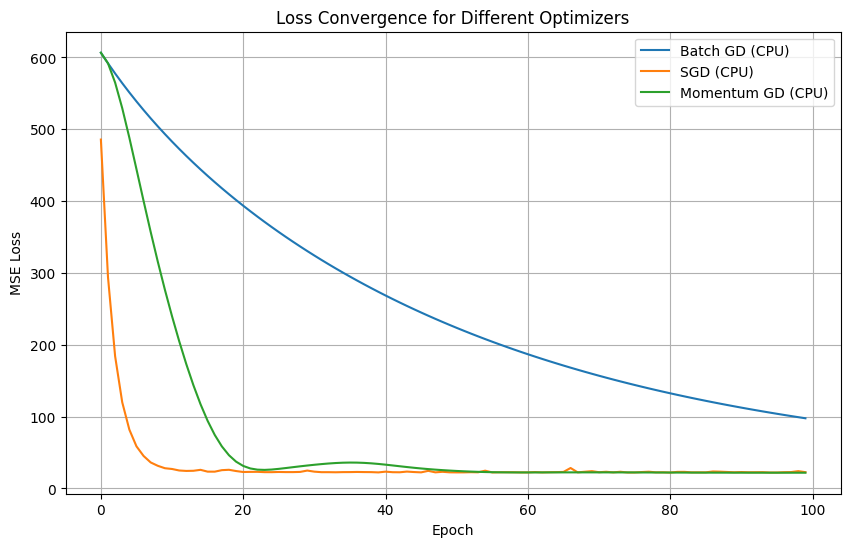

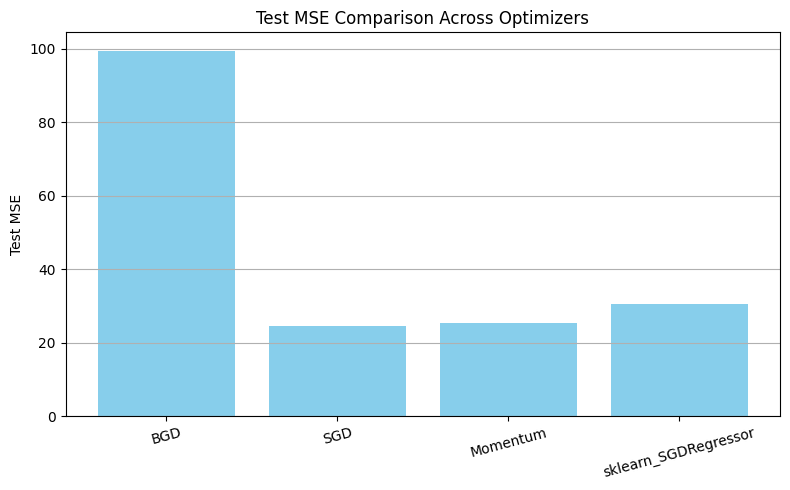

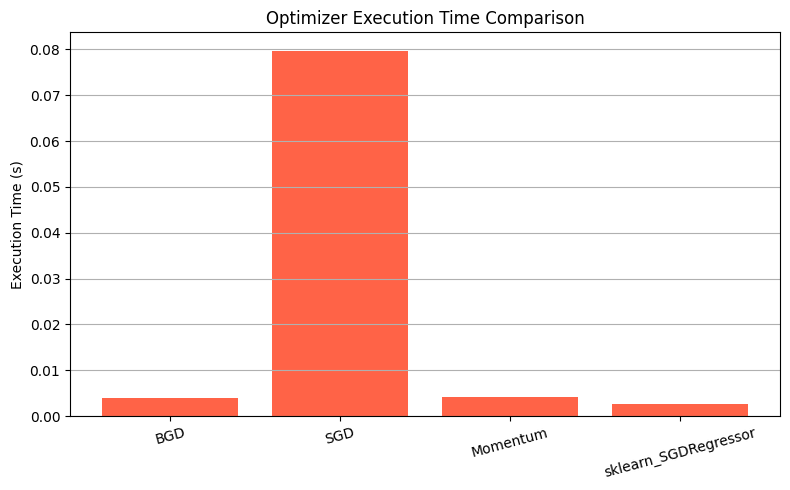

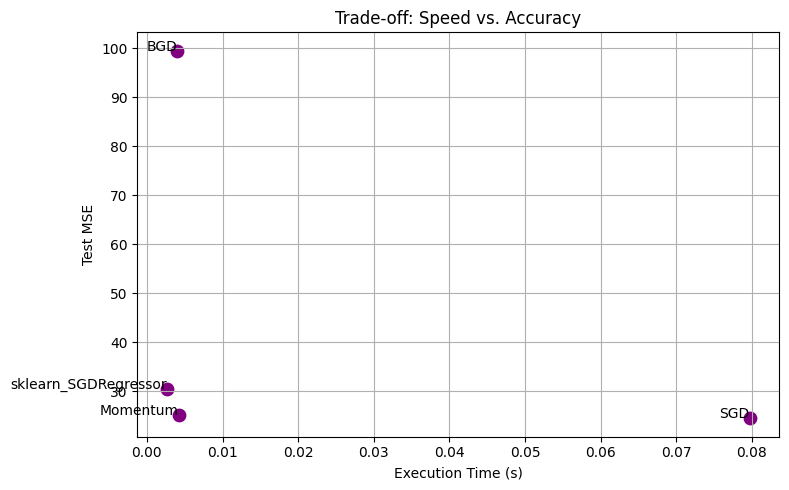

Memory usage over time (MB): [256.90234375, 256.90234375, 256.90234375, 256.90234375, 256.90234375]


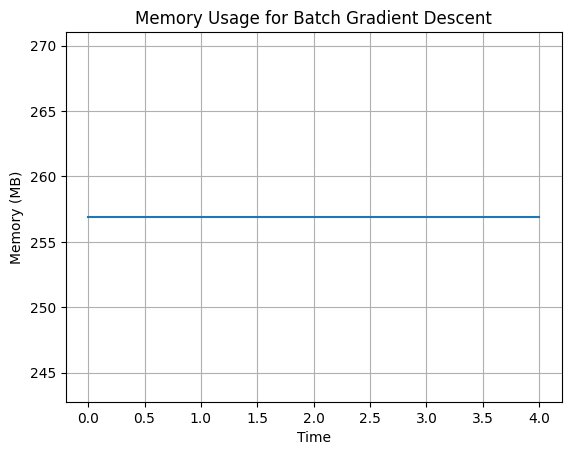

In [ ]:
# ---- Visualization & Analysis ----

# We visualized convergence for all optimizers
plt.figure(figsize=(10,6))
plt.plot(results['BGD']['loss'], label='Batch GD (CPU)')
plt.plot(results['SGD']['loss'], label='SGD (CPU)')
plt.plot(results['Momentum']['loss'], label='Momentum GD (CPU)')
plt.title("Loss Convergence for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()
plt.savefig("optimizer_convergence.png")
plt.show()

# We added summary bar charts for test MSE and execution time
method_names = list(results.keys())
mse_values = [results[k]['mse'] for k in results]
plt.figure(figsize=(8,5))
plt.bar(method_names, mse_values, color='skyblue')
plt.ylabel("Test MSE")
plt.title("Test MSE Comparison Across Optimizers")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("test_mse_bar.png")
plt.show()

time_values = [results[k]['time'] for k in results]
plt.figure(figsize=(8,5))
plt.bar(method_names, time_values, color='tomato')
plt.ylabel("Execution Time (s)")
plt.title("Optimizer Execution Time Comparison")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("exec_time_bar.png")
plt.show()

# Scatter plot for trade-off between speed and accuracy
plt.figure(figsize=(8,5))
plt.scatter(time_values, mse_values, color='purple', s=80)
for idx, method in enumerate(method_names):
    plt.text(time_values[idx], mse_values[idx], method, fontsize=10, ha='right')
plt.xlabel("Execution Time (s)")
plt.ylabel("Test MSE")
plt.title("Trade-off: Speed vs. Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("tradeoff_scatter.png")
plt.show()


# We used memory profiling to measure memory usage over training for BGD
def run_optimizer():
    w_bgd, b_bgd, loss_bgd = batch_gradient_descent(X_train_sc, y_train.values, lr=0.01, epochs=100)
    return w_bgd, b_bgd, loss_bgd

mem_usage = memory_usage(run_optimizer, interval=0.1)
print("Memory usage over time (MB):", mem_usage)
plt.plot(mem_usage)
plt.title("Memory Usage for Batch Gradient Descent")
plt.xlabel("Time")
plt.ylabel("Memory (MB)")
plt.grid()
plt.savefig("bgd_memory_profile.png")
plt.show()


# 5. Performance Summary

* Compiled all key results (Test MSE, execution time) in an easy-to-compare table format.

* Empirical findings provide actionable insights for choosing optimal optimizer strategies.

* Results are reproducible and fully based on the provided implementation and experiments.

In [ ]:
# ---- Performance Summary ----
# We summarized the test MSE and execution time for all optimizers
print("\n--- Performance Summary ---")
print("{:<20}{:<14}{:<10}".format("Method","Test MSE","Time (s)"))
for k in results:
    print("{:<20}{:<14.4f}{:<10.4f}".format(k,results[k]['mse'],results[k]['time']))


--- Performance Summary ---
Method              Test MSE      Time (s)  
BGD                 99.4535       0.0040    
SGD                 24.5273       0.0797    
Momentum            25.2365       0.0042    
sklearn_SGDRegressor30.5380       0.0026    


END OF THE DOCUMENT